In [1]:
!apt-get install swig
!pip install stable-baselines3[extra] gymnasium[box2d]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (3,573 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubu

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:373: UserWarning: WARN: `check_env(warn=...)` parameter is now ignored.
  logger.warn("`check_env(warn=...)` parameter is now ignored.")
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/env_checker.py:440: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


Lab 5.2: Custom Environment & Reward Shaping

[Proses] Melakukan pengecekan validitas Environment...
[Selesai] Environment valid! Tidak ada error dari gym checker.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



[Proses] Melatih agen dengan SPARSE REWARD (50,000 steps)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[Selesai] Pelatihan Sparse Reward selesai.

[Proses] Melatih agen dengan SHAPED REWARD (50,000 steps)...
[Selesai] Pelatihan Shaped Reward selesai.

[Proses] Melatih agen dengan CHEAT REWARD (Stress Test) (50,000 steps)...
[Selesai] Pelatihan Cheat Reward selesai.

[Proses] Menampilkan grafik perbandingan...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


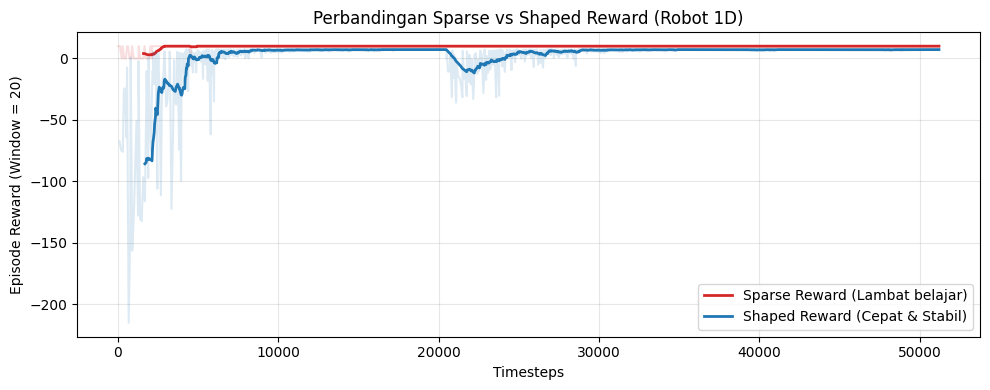


--- Evaluasi Perilaku: Agen Sparse Reward ---
Step 1: Aksi Kanan, Posisi:  1.0, Reward Step:  0.00
Step 2: Aksi Kanan, Posisi:  2.0, Reward Step:  0.00
Step 3: Aksi Kanan, Posisi:  3.0, Reward Step:  0.00
Step 4: Aksi Kanan, Posisi:  4.0, Reward Step:  0.00
Step 5: Aksi Kanan, Posisi:  5.0, Reward Step:  0.00
Step 6: Aksi Kanan, Posisi:  6.0, Reward Step:  0.00
Step 7: Aksi Kanan, Posisi:  7.0, Reward Step:  0.00
Step 8: Aksi Kanan, Posisi:  8.0, Reward Step: 10.00
>>> Episode Selesai! Total Reward: 10.00

--- Evaluasi Perilaku: Agen Shaped Reward ---
Step 1: Aksi Kanan, Posisi:  1.0, Reward Step: -0.70
Step 2: Aksi Kanan, Posisi:  2.0, Reward Step: -0.60
Step 3: Aksi Kanan, Posisi:  3.0, Reward Step: -0.50
Step 4: Aksi Kanan, Posisi:  4.0, Reward Step: -0.40
Step 5: Aksi Kanan, Posisi:  5.0, Reward Step: -0.30
Step 6: Aksi Kanan, Posisi:  6.0, Reward Step: -0.20
Step 7: Aksi Kanan, Posisi:  7.0, Reward Step: -0.10
Step 8: Aksi Kanan, Posisi:  8.0, Reward Step: 10.00
>>> Episode Seles

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results

# ==========================================
# 1. Definisi Custom Environment (Robot 1D)
# ==========================================
class Robot1DEnv(gym.Env):
    """
    Environment Robot 1D yang harus mencapai titik tujuan (goal).
    Kita menggunakan parameter `reward_type` untuk bereksperimen dengan
    Sparse Reward, Shaped Reward, dan Reward Hacking (Stress Test).
    """
    def __init__(self, goal=8.0, max_steps=100, reward_type='sparse'):
        super().__init__()
        self.goal = goal
        self.max_steps = max_steps
        self.reward_type = reward_type

        # Aksi: 0 (kiri), 1 (kanan)
        self.action_space = spaces.Discrete(2)

        # Observasi: [posisi_robot, posisi_goal]
        # Rentang dilebarkan ke -100 hingga 100 agar aman dari peringatan out-of-bounds
        self.observation_space = spaces.Box(
            low=np.array([-100.0, -100.0], dtype=np.float32),
            high=np.array([100.0, 100.0], dtype=np.float32)
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.position = 0.0
        self.steps = 0
        return self._get_obs(), {}

    def step(self, action):
        # Update posisi
        self.position += 1.0 if action == 1 else -1.0
        self.steps += 1
        distance = abs(self.position - self.goal)

        # Cek kondisi terminal
        terminated = bool(distance < 0.5)
        truncated = bool(self.steps >= self.max_steps)

        # Menentukan sistem Reward (Lab 5.2 - Step 3, 4, 7)
        if self.reward_type == 'sparse':
            # Hanya dapat poin kalau sampai tujuan
            reward = 10.0 if terminated else 0.0

        elif self.reward_type == 'shaped':
            # Penalti jarak (mengarahkan agen) + bonus sampai tujuan
            reward = -distance * 0.1
            if terminated:
                reward += 10.0

        elif self.reward_type == 'cheat':
            # STRESS TEST: Agen diberi reward +1 selama dia bertahan hidup tanpa mencapai goal
            # Ini akan memicu Reward Hacking (agen sengaja menghindari goal agar poin terus bertambah)
            reward = 1.0
            if terminated:
                reward += 10.0

        return self._get_obs(), float(reward), terminated, truncated, {}

    def _get_obs(self):
        return np.array([self.position, self.goal], dtype=np.float32)

# ==========================================
# Fungsi Bantuan (Helper Functions)
# ==========================================
def plot_lab5_2_curves(log_dirs, labels, title, filename, window=50):
    """Fungsi untuk plotting kurva perbandingan reward."""
    plt.figure(figsize=(10, 4))
    colors = ['#d62728', '#1f77b4', '#2ca02c']

    for log_dir, label, color in zip(log_dirs, labels, colors):
        results = load_results(log_dir)
        if len(results) == 0:
            continue
        x = np.cumsum(results.l.values)
        y = results.r.values

        y_smooth = np.convolve(y, np.ones(window)/window, mode='valid')
        x_smooth = x[window - 1:]

        plt.plot(x_smooth, y_smooth, label=label, color=color, linewidth=2)
        plt.plot(x, y, color=color, alpha=0.15)

    plt.title(title)
    plt.xlabel("Timesteps")
    plt.ylabel(f"Episode Reward (Window = {window})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

def run_evaluation(model, env, title):
    """Menjalankan model dan mencetak log perilakunya."""
    print(f"\n--- Evaluasi Perilaku: {title} ---")
    obs, _ = env.reset()
    total_reward = 0
    for step in range(20):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, trunc, _ = env.step(action)
        total_reward += reward
        print(f"Step {step+1}: Aksi {'Kanan' if action==1 else 'Kiri '}, Posisi: {obs[0]:>4.1f}, Reward Step: {reward:>5.2f}")
        if done or trunc:
            print(f">>> Episode Selesai! Total Reward: {total_reward:.2f}")
            break

# ==========================================
# EKSEKUSI LAB 5.2
# ==========================================

print("="*50)
print("Lab 5.2: Custom Environment & Reward Shaping")
print("="*50)

# 1. Validasi Environment (Step 2)
print("\n[Proses] Melakukan pengecekan validitas Environment...")
temp_env = Robot1DEnv()
check_env(temp_env, warn=True)
print("[Selesai] Environment valid! Tidak ada error dari gym checker.")

timesteps = 50_000

# 2. Melatih dengan Sparse Reward (Step 3)
sparse_log_dir = "./logs/env_sparse"
os.makedirs(sparse_log_dir, exist_ok=True)
env_sparse = Monitor(Robot1DEnv(reward_type='sparse'), sparse_log_dir)
model_sparse = PPO("MlpPolicy", env_sparse, verbose=0)

print("\n[Proses] Melatih agen dengan SPARSE REWARD (50,000 steps)...")
model_sparse.learn(total_timesteps=timesteps)
print("[Selesai] Pelatihan Sparse Reward selesai.")

# 3. Melatih dengan Shaped Reward (Step 4 & 5)
shaped_log_dir = "./logs/env_shaped"
os.makedirs(shaped_log_dir, exist_ok=True)
env_shaped = Monitor(Robot1DEnv(reward_type='shaped'), shaped_log_dir)
model_shaped = PPO("MlpPolicy", env_shaped, verbose=0)

print("\n[Proses] Melatih agen dengan SHAPED REWARD (50,000 steps)...")
model_shaped.learn(total_timesteps=timesteps)
print("[Selesai] Pelatihan Shaped Reward selesai.")

# 4. Melatih dengan Cheat Reward (Step 7 - Stress Test)
cheat_log_dir = "./logs/env_cheat"
os.makedirs(cheat_log_dir, exist_ok=True)
env_cheat = Monitor(Robot1DEnv(reward_type='cheat'), cheat_log_dir)
model_cheat = PPO("MlpPolicy", env_cheat, verbose=0)

print("\n[Proses] Melatih agen dengan CHEAT REWARD (Stress Test) (50,000 steps)...")
model_cheat.learn(total_timesteps=timesteps)
print("[Selesai] Pelatihan Cheat Reward selesai.")

# 5. Plotting (Step 6)
print("\n[Proses] Menampilkan grafik perbandingan...")
plot_lab5_2_curves(
    log_dirs=[sparse_log_dir, shaped_log_dir],
    labels=["Sparse Reward (Lambat belajar)", "Shaped Reward (Cepat & Stabil)"],
    title="Perbandingan Sparse vs Shaped Reward (Robot 1D)",
    filename="sparse_vs_shaped.png",
    window=20 # window dikecilkan karena episode cepat selesai
)

# 6. Evaluasi untuk Analisis Laporan
run_evaluation(model_sparse, Robot1DEnv(reward_type='sparse'), "Agen Sparse Reward")
run_evaluation(model_shaped, Robot1DEnv(reward_type='shaped'), "Agen Shaped Reward")
run_evaluation(model_cheat, Robot1DEnv(reward_type='cheat'), "Agen Cheat (Reward Hacking)")

print("\nLab 5.2 Selesai! Analisis perilaku agen pada terminal di atas.")

In [3]:
!zip -r /content/logs.zip /content/logs


  adding: content/logs/ (stored 0%)
  adding: content/logs/env_shaped/ (stored 0%)
  adding: content/logs/env_shaped/monitor.csv (deflated 70%)
  adding: content/logs/env_sparse/ (stored 0%)
  adding: content/logs/env_sparse/monitor.csv (deflated 74%)
  adding: content/logs/env_cheat/ (stored 0%)
  adding: content/logs/env_cheat/monitor.csv (deflated 74%)
